In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# MSD Dataset Exploration

In [2]:
import pickle
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import matplotlib.patches as mpatches

DATA_PATH = "../data/modified-swiss-dwellings-v2/train/"

ROOM_NAMES  = {0:'Balcony',1:'Bathroom',2:'Bedroom',3:'Corridor',4:'Dining',5:'Kitchen',6:'Living Room',7:'Storeroom',8:'Other'}
ROOM_COLORS = {0:'#AED6F1',1:'#A9DFBF',2:'#F9E79F',3:'#F0B27A',4:'#D7BDE2',5:'#F1948A',6:'#85C1E9',7:'#D5DBDB',8:'#FDFEFE'}
ZONE_COLORS = ['#E8DAEF', '#D5F5E3', '#FDEBD0', '#D6EAF8']
ZONE_NAMES  = {0:'Zone 0 (Living)', 1:'Zone 1 (Dynamic)', 2:'Zone 2 (Static)', 3:'Zone 3 (Functional)'}

def load(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def draw_plan(ax, g_out, title):
    for node, data in g_out.nodes(data=True):
        geom = data.get('geometry')
        room_type = data.get('room_type', 8)
        centroid = data.get('centroid')
        if geom is None:
            continue
        coords = list(geom.exterior.coords) if hasattr(geom, 'exterior') else geom
        poly = MplPolygon(coords, closed=True,
                          facecolor=ROOM_COLORS.get(room_type, '#fff'),
                          edgecolor='black', linewidth=1)
        ax.add_patch(poly)
        if centroid is not None:
            cx = centroid.x if hasattr(centroid, 'x') else centroid[0]
            cy = centroid.y if hasattr(centroid, 'y') else centroid[1]
            ax.text(cx, cy, ROOM_NAMES.get(room_type, '?'), fontsize=7, ha='center', va='center')
    ax.autoscale()
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=9)

print('Ready.')

Ready.


Plan 10000 — 41 rooms, 39 connections

Room breakdown:
  Balcony      x13
  Bedroom      x5
  Dining       x7
  Kitchen      x2
  Living Room  x2
  Storeroom    x6
  Other        x6

Connectivity types: {'entrance', 'door'}


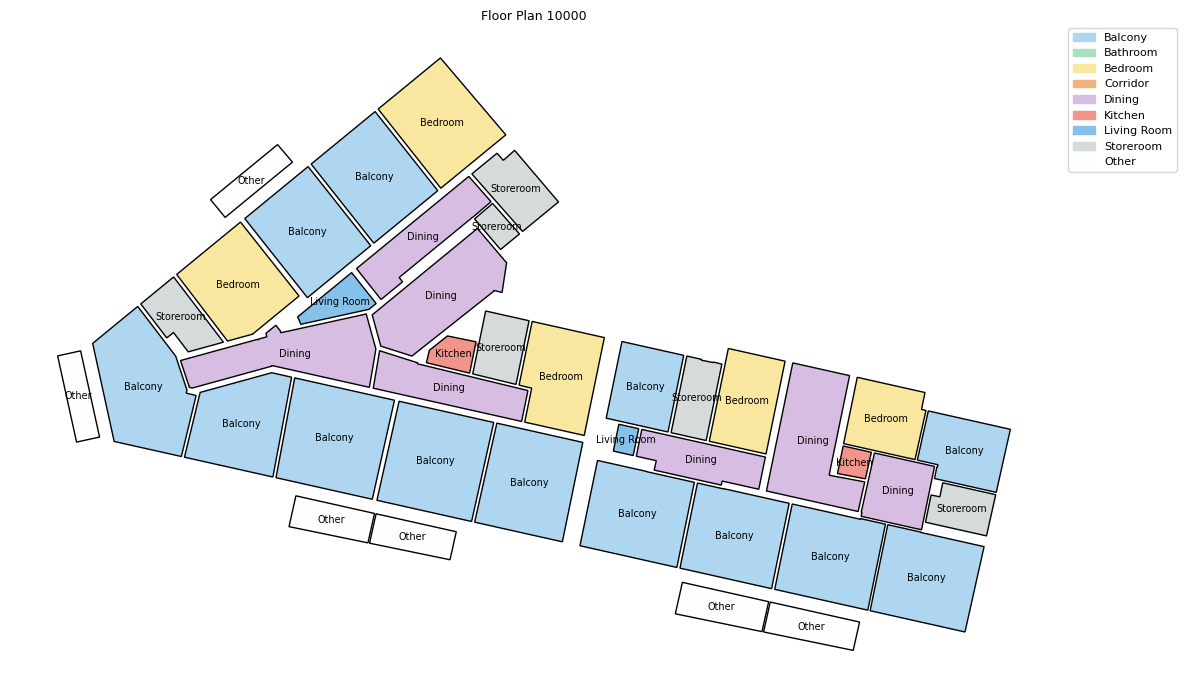

In [3]:
# ── Single floor plan inspector ───────────────────────────────────────────────
PLAN_ID = '10000'

g_out = load(DATA_PATH + f'graph_out/{PLAN_ID}.pickle')
g_in  = load(DATA_PATH + f'graph_in/{PLAN_ID}.pickle')

print(f'Plan {PLAN_ID} — {g_out.number_of_nodes()} rooms, {g_out.number_of_edges()} connections')
print('\nRoom breakdown:')
from collections import Counter
counts = Counter(d['room_type'] for _, d in g_out.nodes(data=True))
for rt, n in sorted(counts.items()):
    print(f'  {ROOM_NAMES[rt]:12s} x{n}')
print('\nConnectivity types:', set(d['connectivity'] for _,_,d in g_in.edges(data=True)))

fig, ax = plt.subplots(figsize=(12, 7))
draw_plan(ax, g_out, f'Floor Plan {PLAN_ID}')
legend = [mpatches.Patch(color=ROOM_COLORS[k], label=ROOM_NAMES[k]) for k in ROOM_NAMES]
ax.legend(handles=legend, fontsize=8,
          bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

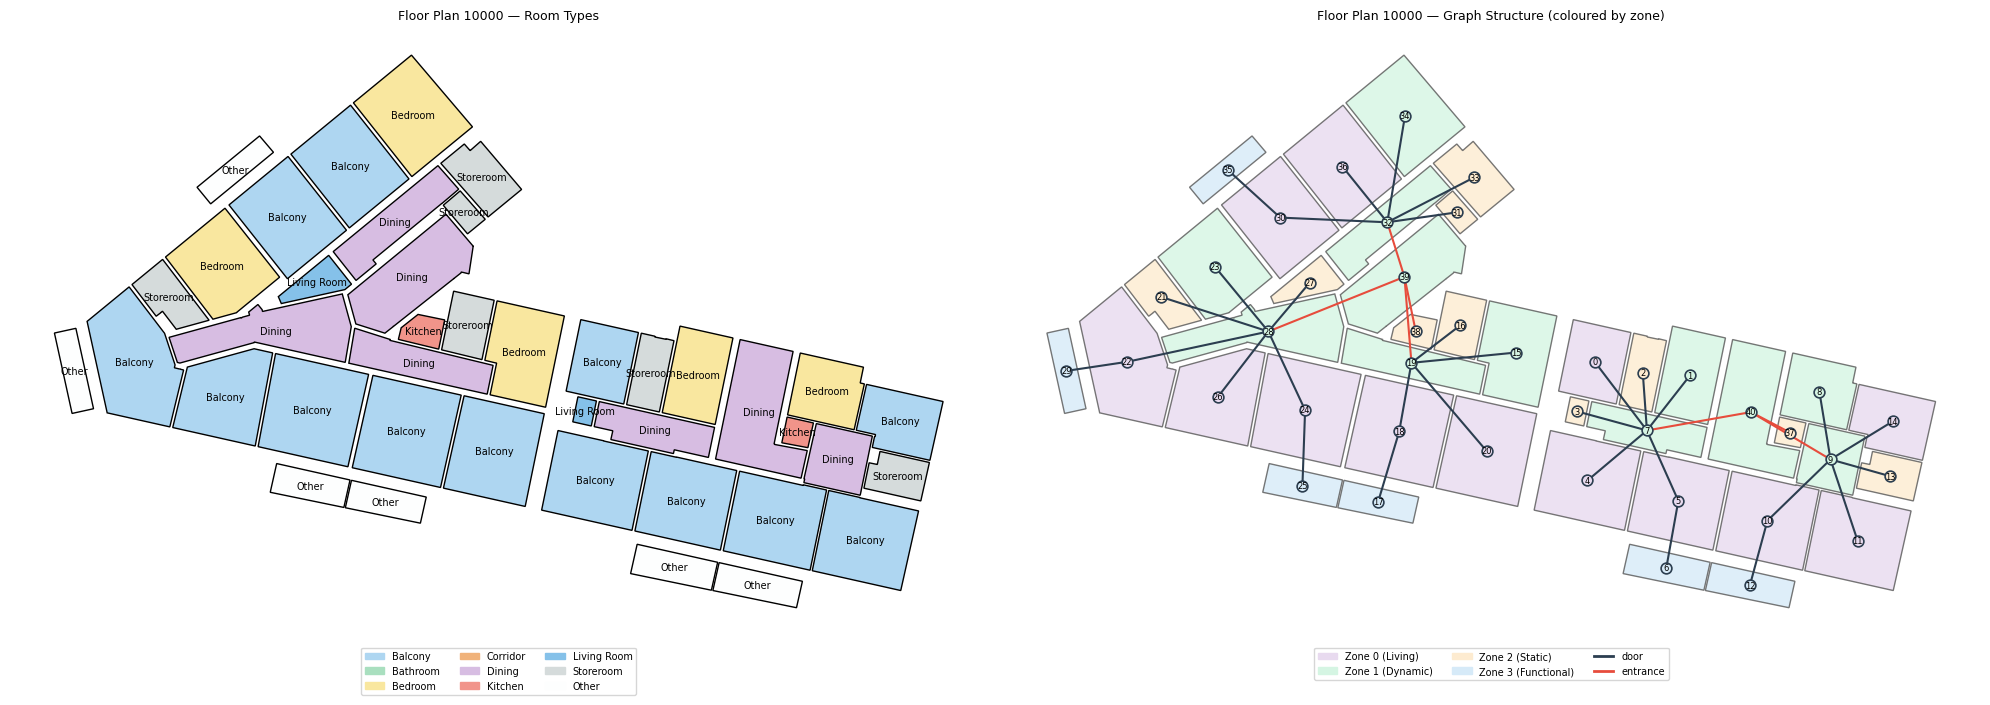

In [4]:
# ── Graph structure overlay ───────────────────────────────────────────────────
PLAN_ID = '10000'

g_out = load(DATA_PATH + f'graph_out/{PLAN_ID}.pickle')
g_in  = load(DATA_PATH + f'graph_in/{PLAN_ID}.pickle')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: room types
draw_plan(axes[0], g_out, f'Floor Plan {PLAN_ID} — Room Types')
legend_rooms = [mpatches.Patch(color=ROOM_COLORS[k], label=ROOM_NAMES[k]) for k in ROOM_NAMES]
axes[0].legend(handles=legend_rooms, fontsize=7,
               bbox_to_anchor=(0.5, -0.02), loc='upper center',
               ncol=3, borderaxespad=0)

# Right: zone + graph overlay
ax = axes[1]
for node, data in g_out.nodes(data=True):
    geom = data.get('geometry')
    if geom is None:
        continue
    zone = g_in.nodes[node].get('zoning_type', 0)
    coords = list(geom.exterior.coords) if hasattr(geom, 'exterior') else geom
    poly = MplPolygon(coords, closed=True,
                      facecolor=ZONE_COLORS[zone % len(ZONE_COLORS)],
                      edgecolor='#555', linewidth=1, alpha=0.8)
    ax.add_patch(poly)

pos = {}
for node, data in g_out.nodes(data=True):
    c = data.get('centroid')
    if c is not None:
        pos[node] = (c.x if hasattr(c, 'x') else c[0], c.y if hasattr(c, 'y') else c[1])

for u, v, edata in g_in.edges(data=True):
    if u in pos and v in pos:
        x0, y0 = pos[u]; x1, y1 = pos[v]
        color = '#E74C3C' if edata.get('connectivity') == 'entrance' else '#2C3E50'
        ax.plot([x0, x1], [y0, y1], color=color, linewidth=1.5, zorder=2)

for node, (x, y) in pos.items():
    zone = g_in.nodes[node].get('zoning_type', 0)
    ax.scatter(x, y, s=60, color=ZONE_COLORS[zone % len(ZONE_COLORS)],
               edgecolors='#2C3E50', linewidths=1.2, zorder=3)
    ax.text(x, y, str(node), fontsize=6, ha='center', va='center', zorder=4)

ax.autoscale()
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Floor Plan {PLAN_ID} — Graph Structure (coloured by zone)', fontsize=9)

legend_zones = [mpatches.Patch(color=ZONE_COLORS[k], label=ZONE_NAMES[k]) for k in ZONE_NAMES]
legend_edges = [plt.Line2D([0],[0], color='#2C3E50', lw=2, label='door'),
                plt.Line2D([0],[0], color='#E74C3C', lw=2, label='entrance')]
ax.legend(handles=legend_zones + legend_edges, fontsize=7,
          bbox_to_anchor=(0.5, -0.02), loc='upper center',
          ncol=3, borderaxespad=0)

plt.tight_layout()
plt.show()

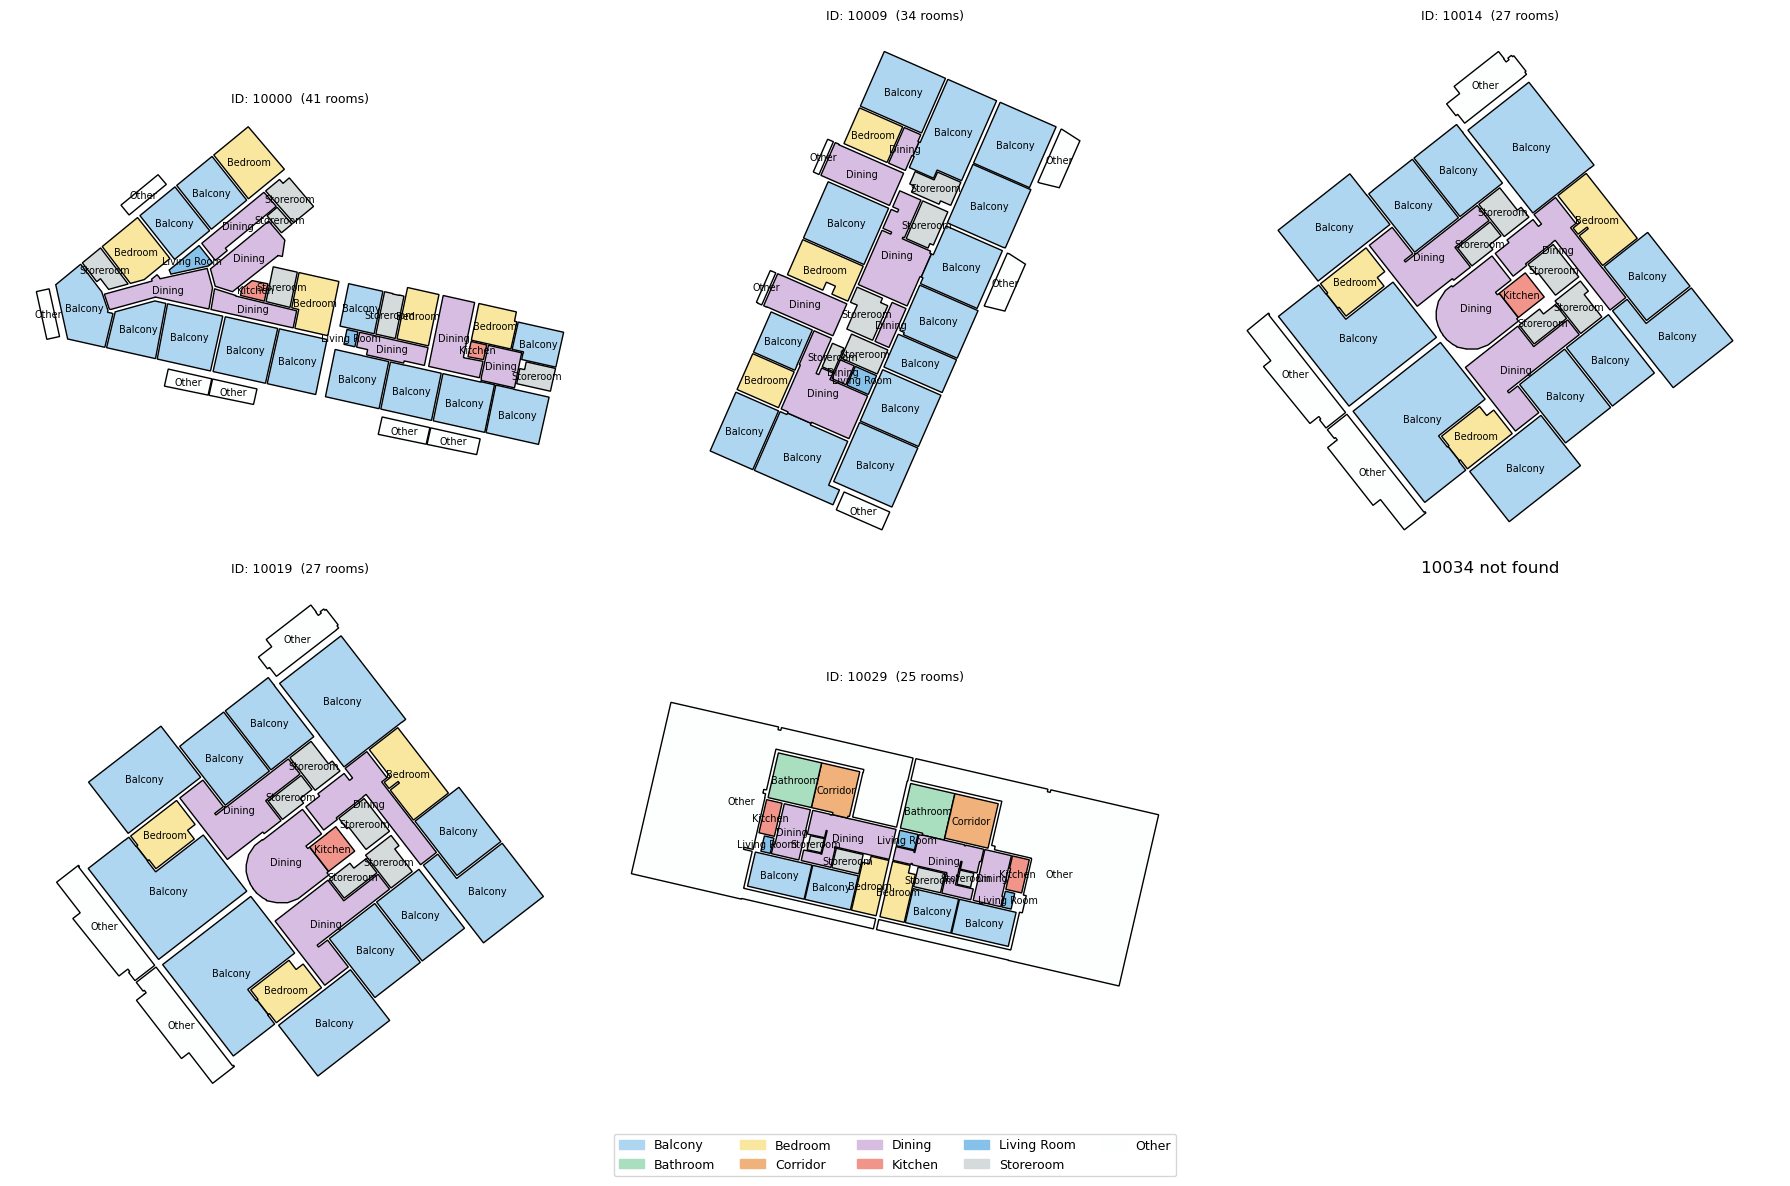

In [5]:
# ── Browse multiple plans at once ─────────────────────────────────────────────
PLAN_IDS = ['10000', '10009', '10014', '10019', '10029', '10034']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, pid in zip(axes.flat, PLAN_IDS):
    try:
        g = load(DATA_PATH + f'graph_out/{pid}.pickle')
        draw_plan(ax, g, f'ID: {pid}  ({g.number_of_nodes()} rooms)')
    except FileNotFoundError:
        ax.axis('off')
        ax.set_title(f'{pid} not found')

legend = [mpatches.Patch(color=ROOM_COLORS[k], label=ROOM_NAMES[k]) for k in ROOM_NAMES]
fig.legend(handles=legend, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [6]:
# ── List available plan IDs ───────────────────────────────────────────────────
import os
all_ids = sorted([f.replace('.pickle','') for f in os.listdir(DATA_PATH + 'graph_out/')])
print(f'{len(all_ids)} plans available. First 30:')
print(all_ids[:30])

4572 plans available. First 30:
['10000', '10009', '10014', '10019', '10029', '10031', '10051', '10053', '10056', '10064', '10075', '10079', '10080', '10082', '10083', '10084', '10085', '10086', '10087', '10089', '10090', '10093', '10094', '10097', '10117', '10119', '10120', '10124', '10126', '10128']
